# Tratamento da Estação Irajá

Este notebook organiza o tratamento horário da Estação `Irajá` em três blocos simples:

1. Padronizar o calendário horário;
2. Interpolar apenas lacunas internas curtas;
3. Validar o impacto do tratamento.

A proposta aqui é fazer o básico bem feito, de forma rastreável e reutilizável para as próximas estações.


## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from decimal import Decimal, ROUND_HALF_EVEN

## Carregamento da base da estação

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da estação para evitar problemas de codificação e isolamos apenas os registros da estação `Irajá`.


In [14]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_iraja = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO IRAJÁ"].copy()

df_iraja["data"] = pd.to_datetime(df_iraja["data"])
df_iraja = df_iraja.sort_values("data").reset_index(drop=True)
df_iraja = df_iraja.drop_duplicates(subset="data", keep="first")
df_iraja = df_iraja.set_index("data").sort_index().copy()

print("Dimensoes da base da Estacao Irajá:", df_iraja.shape)
display(df_iraja.head())

Dimensoes da base da Estacao Irajá: (61368, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2012-01-01 00:30:00,ESTAÇÃO IRAJÁ,0.8,24.84,97.12,2.55,20.09,0.40,0.23,20.20,25.03,89.0,85.0,-22.831621,-43.326845
2012-01-01 01:30:00,ESTAÇÃO IRAJÁ,0.0,24.68,96.00,0.45,18.91,0.35,0.68,19.60,22.95,33.0,32.0,-22.831621,-43.326845
2012-01-01 02:30:00,ESTAÇÃO IRAJÁ,0.0,24.56,96.39,0.11,17.99,0.34,0.39,18.33,22.31,19.0,14.0,-22.831621,-43.326845
2012-01-01 03:30:00,ESTAÇÃO IRAJÁ,0.0,24.65,96.87,0.70,22.49,0.37,0.44,22.93,17.98,12.0,12.0,-22.831621,-43.326845
2012-01-01 04:30:00,ESTAÇÃO IRAJÁ,0.0,24.66,96.32,0.79,21.28,0.32,0.24,21.52,18.88,10.0,10.0,-22.831621,-43.326845


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de dados faltantes antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.


In [15]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_iraja, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
so2,16327,26.61,45041
ur,10907,17.77,50461
pm2_5,5968,9.72,55400
o3,5103,8.32,56265
nox,5048,8.23,56320
no,5043,8.22,56325
no2,5041,8.21,56327
temp,4190,6.83,57178
pm10,4049,6.60,57319
co,3653,5.95,57715


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- Interpolar apenas lacunas internas de até `4` horas consecutivas;
- Não extrapolar bordas da série;
- Não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.


In [16]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_iraja_tratado = df_iraja.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_iraja[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_iraja_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"



    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_iraja_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
2,so2,interpolate_time,16327,14081,2246
3,pm2_5,interpolate_time,5968,3952,2016
9,pm10,interpolate_time,4049,2555,1494
0,no,interpolate_time,5043,3987,1056
4,nox,interpolate_time,5048,3996,1052
1,no2,interpolate_time,5041,3991,1050
8,co,interpolate_time,3653,3027,626
7,o3,interpolate_time,5103,4499,604
5,ur,interpolate_time,10907,10553,354
6,temp,interpolate_time,4190,3843,347


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- Redução dos dados faltantes por variável;
- Estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir parte das lacunas sem alterar, de forma relevante, o comportamento geral das séries.


Total de valores imputados: 10845


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
so2,16327,26.61,14081,22.95,2246,13.76
pm2_5,5968,9.72,3952,6.44,2016,33.78
pm10,4049,6.60,2555,4.16,1494,36.90
no,5043,8.22,3987,6.50,1056,20.94
nox,5048,8.23,3996,6.51,1052,20.84
no2,5041,8.21,3991,6.50,1050,20.83
co,3653,5.95,3027,4.93,626,17.14
o3,5103,8.32,4499,7.33,604,11.84
ur,10907,17.77,10553,17.20,354,3.25
temp,4190,6.83,3843,6.26,347,8.28


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
no,19.232069,7.20,35.773231,19.118439,7.16,35.638444,-0.113629,-0.134787
no2,41.956282,38.63,20.506189,41.871990,38.52,20.500118,-0.084293,-0.006071
so2,3.285312,1.65,6.396173,3.303433,1.68,6.347818,0.018122,-0.048356
pm2_5,17.534946,14.00,14.805852,17.457277,14.00,14.759748,-0.077669,-0.046103
nox,61.174788,47.54,48.740547,60.970506,47.36,48.590224,-0.204282,-0.150323
ur,66.323276,68.50,17.942400,66.311316,68.47,17.968855,-0.011960,0.026455
temp,27.421394,26.72,4.908576,27.431672,26.73,4.909619,0.010278,0.001043
o3,33.360380,24.43,33.401473,33.473995,24.60,33.419646,0.113615,0.018172
co,0.447750,0.39,0.299495,0.447838,0.39,0.299060,0.000088,-0.000435
pm10,38.020935,32.00,24.579275,37.874620,32.00,24.575408,-0.146316,-0.003868


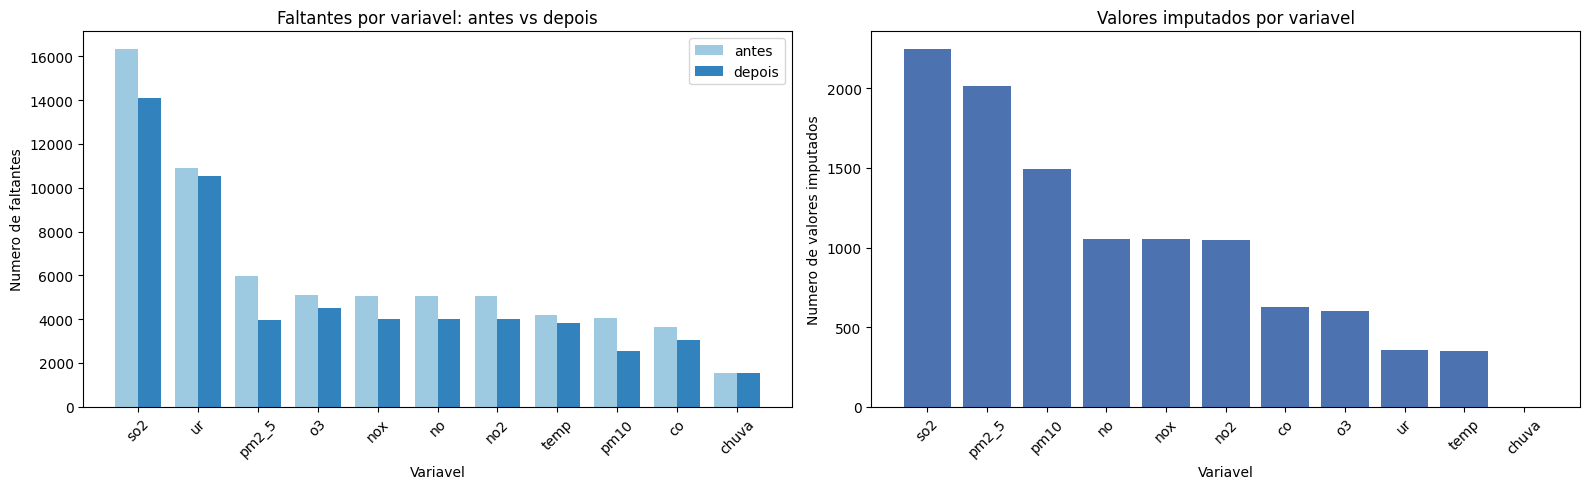

In [17]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_iraja_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_iraja[variavel].notna().any() or df_iraja_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_iraja, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_iraja_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Calculo do Indice de Qualidade do Ar (AQI)

Nesta etapa, calculamos o AQI diario da estacao com base no documento tecnico de janeiro/2025 (IQAr), alinhado a Resolucao Conama no 506/2024.

### 1) Premissas regulatorias adotadas

Usamos a mesma logica descrita no documento:

- Calculamos um subindice por poluente (`pm10`, `pm2_5`, `o3`, `co`, `no2`, `so2`);
- O AQI diario e o maior subindice do dia;
- `o3` e `co`: maxima da media movel de 8 horas no dia;
- `no2`: maxima horaria no dia;
- `pm10`, `pm2_5` e `so2`: media de 24 horas;
- Arredondamento bancario (`ROUND_HALF_EVEN`):
  - `co` com 1 casa decimal;
  - demais poluentes sem casa decimal;
  - indice final arredondado para inteiro.

### 2) Tabela de faixas e implementacao

As faixas abaixo reproduzem o Quadro 1 do documento e sao aplicadas na interpolacao linear do indice em cada intervalo.


In [18]:
# Faixas de concentracao e indice (IQAr) conforme orientacao tecnica (jan/2025).
FAIXAS_IQAR = {
    'pm10_24h': [
        {'c_ini': 0, 'c_fin': 45, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 46, 'c_fin': 100, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 101, 'c_fin': 150, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 151, 'c_fin': 250, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 251, 'c_fin': 600, 'i_ini': 201, 'i_fin': 400},
    ],
    'pm2_5_24h': [
        {'c_ini': 0, 'c_fin': 15, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 16, 'c_fin': 50, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 51, 'c_fin': 75, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 76, 'c_fin': 125, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 126, 'c_fin': 300, 'i_ini': 201, 'i_fin': 400},
    ],
    'o3_8h_max': [
        {'c_ini': 0, 'c_fin': 100, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 101, 'c_fin': 130, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 131, 'c_fin': 160, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 161, 'c_fin': 200, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 201, 'c_fin': 800, 'i_ini': 201, 'i_fin': 400},
    ],
    'co_8h_max': [
        {'c_ini': 0.0, 'c_fin': 9.0, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 9.1, 'c_fin': 11.0, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 11.1, 'c_fin': 13.0, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 13.1, 'c_fin': 15.0, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 15.1, 'c_fin': 50.0, 'i_ini': 201, 'i_fin': 400},
    ],
    'no2_1h_max': [
        {'c_ini': 0, 'c_fin': 200, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 201, 'c_fin': 240, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 241, 'c_fin': 320, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 321, 'c_fin': 1130, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 1131, 'c_fin': 3750, 'i_ini': 201, 'i_fin': 400},
    ],
    'so2_24h': [
        {'c_ini': 0, 'c_fin': 40, 'i_ini': 0, 'i_fin': 40},
        {'c_ini': 41, 'c_fin': 50, 'i_ini': 41, 'i_fin': 80},
        {'c_ini': 51, 'c_fin': 125, 'i_ini': 81, 'i_fin': 120},
        {'c_ini': 126, 'c_fin': 800, 'i_ini': 121, 'i_fin': 200},
        {'c_ini': 801, 'c_fin': 2620, 'i_ini': 201, 'i_fin': 400},
    ],
}

def arredondar_bancario(valor: float, casas_decimais: int):
    """Aplica arredondamento ROUND_HALF_EVEN (arredondamento bancario)."""
    if pd.isna(valor):
        return pd.NA

    quantizador = Decimal('1') if casas_decimais == 0 else Decimal('0.1')
    valor_decimal = Decimal(str(valor)).quantize(quantizador, rounding=ROUND_HALF_EVEN)

    if casas_decimais == 0:
        return int(valor_decimal)
    return float(valor_decimal)

def calcular_subindice_iqar(concentracao: float, faixas: list[dict]):
    """Calcula o subindice de um poluente por interpolacao linear na faixa correspondente."""
    if pd.isna(concentracao):
        return pd.NA

    for faixa in faixas:
        if faixa['c_ini'] <= concentracao <= faixa['c_fin']:
            inclinacao = (faixa['i_fin'] - faixa['i_ini']) / (faixa['c_fin'] - faixa['c_ini'])
            indice = faixa['i_ini'] + inclinacao * (concentracao - faixa['c_ini'])
            return int(Decimal(str(indice)).quantize(Decimal('1'), rounding=ROUND_HALF_EVEN))

    # O Quadro 1 vai ate IQAr=400 (N5 - Pessima); acima do teto, saturamos no valor maximo.
    if concentracao > faixas[-1]['c_fin']:
        return 400

    return pd.NA

def classificar_iqar(indice: float):
    """Converte o indice numerico em faixa textual de qualidade do ar."""
    if pd.isna(indice):
        return pd.NA

    indice_int = int(indice)
    if indice_int <= 40:
        return 'N1 - Boa'
    if indice_int <= 80:
        return 'N2 - Moderada'
    if indice_int <= 120:
        return 'N3 - Ruim'
    if indice_int <= 200:
        return 'N4 - Muito Ruim'
    return 'N5 - Pessima'

def identificar_poluente_dominante(linha_subindices: pd.Series):
    """Retorna o poluente com maior subindice no dia."""
    validos = linha_subindices.dropna()
    if validos.empty:
        return pd.NA
    return validos.idxmax().replace('subindice_', '')

# Metricas diarias de entrada para o IQAr.
metricas_iqar_diarias = pd.DataFrame(index=df_iraja_tratado.resample('D').size().index)
metricas_iqar_diarias['pm10_24h'] = df_iraja_tratado['pm10'].resample('D').mean()
metricas_iqar_diarias['pm2_5_24h'] = df_iraja_tratado['pm2_5'].resample('D').mean()
metricas_iqar_diarias['so2_24h'] = df_iraja_tratado['so2'].resample('D').mean()
metricas_iqar_diarias['no2_1h_max'] = df_iraja_tratado['no2'].resample('D').max()

# Para O3 e CO, usamos a maxima da media movel de 8h em cada dia.
metricas_iqar_diarias['o3_8h_max'] = (
    df_iraja_tratado['o3']
    .rolling(window=8, min_periods=8)
    .mean()
    .resample('D')
    .max()
)
metricas_iqar_diarias['co_8h_max'] = (
    df_iraja_tratado['co']
    .rolling(window=8, min_periods=8)
    .mean()
    .resample('D')
    .max()
)

# Padronizacao de arredondamento antes do calculo dos indices.
for coluna in ['pm10_24h', 'pm2_5_24h', 'o3_8h_max', 'no2_1h_max', 'so2_24h']:
    metricas_iqar_diarias[coluna] = metricas_iqar_diarias[coluna].apply(
        lambda valor: arredondar_bancario(valor, casas_decimais=0)
    )

metricas_iqar_diarias['co_8h_max'] = metricas_iqar_diarias['co_8h_max'].apply(
    lambda valor: arredondar_bancario(valor, casas_decimais=1)
)

# Calculo dos subindices por poluente.
mapeamento_subindices = {
    'pm10_24h': 'subindice_pm10',
    'pm2_5_24h': 'subindice_pm2_5',
    'o3_8h_max': 'subindice_o3',
    'co_8h_max': 'subindice_co',
    'no2_1h_max': 'subindice_no2',
    'so2_24h': 'subindice_so2',
}

subindices_iqar_diarios = pd.DataFrame(index=metricas_iqar_diarias.index)
for metrica, coluna_subindice in mapeamento_subindices.items():
    subindices_iqar_diarios[coluna_subindice] = metricas_iqar_diarias[metrica].apply(
        lambda concentracao: calcular_subindice_iqar(concentracao, FAIXAS_IQAR[metrica])
    )

# AQI diario = maior subindice entre os poluentes monitorados.
resumo_aqi_diario = pd.DataFrame(index=subindices_iqar_diarios.index)
resumo_aqi_diario['aqi'] = (
    subindices_iqar_diarios
    .apply(pd.to_numeric, errors='coerce')
    .max(axis=1, skipna=True)
    .astype('Int64')
)
resumo_aqi_diario['aqi_qualidade'] = resumo_aqi_diario['aqi'].apply(classificar_iqar)
resumo_aqi_diario['aqi_poluente_dominante'] = subindices_iqar_diarios.apply(
    identificar_poluente_dominante,
    axis=1,
)

display(resumo_aqi_diario.head())
display(subindices_iqar_diarios.head())


,aqi,aqi_qualidade,aqi_poluente_dominante
data,,,
2012-01-01,37,N1 - Boa,pm2_5
2012-01-02,14,N1 - Boa,no2
2012-01-03,20,N1 - Boa,pm10
2012-01-04,37,N1 - Boa,pm2_5
2012-01-05,29,N1 - Boa,pm2_5


,subindice_pm10,subindice_pm2_5,subindice_o3,subindice_co,subindice_no2,subindice_so2
data,,,,,,
2012-01-01,18,37,8,4,11,1
2012-01-02,9,11,6,3,14,2
2012-01-03,20,16,14,2,14,3
2012-01-04,35,37,20,3,18,5
2012-01-05,25,29,24,2,20,4


## Salvamento da base tratada

Por fim, salvamos a Estação `Iraja`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [20]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_iraja_diario = (
    df_iraja_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

# Incluimos o AQI diario e a classificacao de qualidade do ar calculados na secao anterior.
colunas_aqi_exportacao = resumo_aqi_diario[["aqi", "aqi_qualidade"]].rename(
    columns={"aqi_qualidade": "qualidade_do_ar"}
)
df_iraja_diario = df_iraja_diario.join(colunas_aqi_exportacao, how="left")

df_iraja_diario_saida = df_iraja_diario.reset_index()
output_csv_diario_path = output_dir / "iraja_tratado_diario.csv"
df_iraja_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_iraja_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\iraja_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva,aqi,qualidade_do_ar
0,2012-01-01,4.048333,32.075000,1.250000,14.391667,36.115000,93.015417,25.954583,16.853750,0.561250,20.008333,52.4,37,N1 - Boa
1,2012-01-02,22.393333,46.609167,1.701667,4.150000,68.999583,97.525833,22.710833,7.199167,0.491250,10.450000,85.2,14,N1 - Boa
2,2012-01-03,22.157500,48.230000,3.079583,5.916667,70.389583,72.044167,25.730000,14.349583,0.370417,21.833333,0.0,20,N1 - Boa
3,2012-01-04,26.124583,54.517917,4.853333,14.437500,80.644583,70.102500,27.112083,19.756667,0.459583,38.958333,0.0,37,N1 - Boa
4,2012-01-05,8.100000,43.687083,4.303750,10.708333,51.789167,71.318333,27.807083,33.773333,0.330833,27.500000,0.0,29,N1 - Boa


## Resumo interpretativo do tratamento

O tratamento aplicado na estação `Irajá` manteve uma estratégia conservadora (interpolação temporal em lacunas curtas, até `4` horas) e aumentou a completude sem alterar, de forma relevante, o comportamento geral das séries. No total, foram imputados `10845` valores, com maior contribuição em `so2` (`2246`), `pm2_5` (`2016`) e `pm10` (`1494`), seguidos por `no` (`1056`), `nox` (`1052`) e `no2` (`1050`).

As reduções de dados faltantes foram mais fortes em `pm10` (`6,60%` para `4,16%`) e `pm2_5` (`9,72%` para `6,44%`), além de ganhos relevantes em `no` (`8,22%` para `6,50%`), `no2` (`8,21%` para `6,50%`) e `nox` (`8,23%` para `6,51%`). Em `so2`, houve queda de `26,61%` para `22,95%`, enquanto `co`, `o3`, `ur` e `temp` também apresentaram melhora. `chuva` permaneceu sem imputação.

A comparação estatística antes e depois mostra variações pequenas em `média`, `mediana` e `desvio_padrao`, sugerindo ganho de completude com baixo risco de distorção das distribuições originais.
